# 00 · SlideRule data

Requests ATL06-like elevation segments for one ICESat-2 track (RGT) from [SlideRule](https://slideruleearth.io), generated from ATL03 photons at a custom resolution (default 5 m, 40 m segments), limited to the AOI polygon and date range.

The standardized result is cached as `<sliderule_cache_dir>/<track>/ATL06_5m.gpkg`, so the other notebooks and batch runs don't hit the service again.

Requires the package installed from the repository root (`pip install -e .`).
Paths come from `configs/north_slope.toml`; all parameters and their defaults are in `src/is2retreat/config.py`.

In [1]:
TRACK_ID = "0129"
CONFIG = "../configs/north_slope.toml"
SOURCE = "auto"   # "auto": download only if no cache yet | "sliderule": always download | "cache": cache only

In [2]:
import matplotlib.pyplot as plt
import pandas as pd

from is2retreat import load_config
from is2retreat.inputs import load_bluff_shoreline, load_track_beams, resolve_utm_epsg
from is2retreat.utils import format_track_id

TRACK_ID = format_track_id(TRACK_ID)
paths, params = load_config(CONFIG)
print("Cache file:", paths.sliderule_cache_file(TRACK_ID, params.RES_TAG))
print(f"SlideRule: {params.SLIDERULE_DATE_START} → {params.SLIDERULE_DATE_END}, "
      f"len={params.SLIDERULE_SEGMENT_LENGTH_M} m, res={params.SLIDERULE_SEGMENT_RESOLUTION_M} m")

Cache file: /Users/rafael/code/arctic/data/0129/ATL06_5m.gpkg
SlideRule: 2019-01-01 → 2025-12-31, len=40.0 m, res=5.0 m


## UTM zone

The North Slope spans UTM zones 3N–7N, so each track gets the zone of its RGT segment inside the AOI.

In [3]:
utm_epsg = resolve_utm_epsg(TRACK_ID, paths, params)

TRACK_ID=0129: centroid (lon, lat) = (-153.798503, 70.883587) -> UTM_EPSG=32605


## Download (or load) the beams

In [4]:
beams = load_track_beams(TRACK_ID, paths, params, utm_epsg, source=SOURCE)
beams[["beam_id", "gt_family", "acq_date", "cycle", "h_li", "geometry"]].head()

[SR] Loaded cached SlideRule beams: /Users/rafael/code/arctic/data/0129/ATL06_5m.gpkg


,beam_id,gt_family,acq_date,cycle,h_li,geometry
0,sliderule_0129_gt3l_cyc20_20230628,gt3,2023-06-28 15:23:53.804,20,-0.044468,POINT (474061.601 7862894.171)
1,sliderule_0129_gt3l_cyc20_20230628,gt3,2023-06-28 15:23:53.805,20,-0.030886,POINT (474061.034 7862899.137)
2,sliderule_0129_gt3l_cyc20_20230628,gt3,2023-06-28 15:23:53.806,20,-0.000899,POINT (474060.467 7862904.102)
3,sliderule_0129_gt3l_cyc20_20230628,gt3,2023-06-28 15:23:53.806,20,-0.054977,POINT (474060.11 7862907.281)
4,sliderule_0129_gt3l_cyc20_20230628,gt3,2023-06-28 15:23:53.807,20,-0.055889,POINT (474059.516 7862912.509)


## What came back

Each `beam_id` is one beam (`gt1l`, `gt1r`, ...) of one cycle: `sliderule_<track>_<beam>_cyc<NN>_<date>`.

In [5]:
beams["date"] = pd.to_datetime(beams["acq_date"]).dt.normalize()
per_family = beams.groupby("gt_family").agg(
    beams=("beam_id", "nunique"),
    dates=("date", "nunique"),
    points=("beam_id", "size"),
    first=("date", "min"),
    last=("date", "max"),
)
per_family

,beams,dates,points,first,last
gt_family,,,,,
gt1,42,23,27722,2019-01-05,2025-06-24
gt2,41,23,24644,2019-01-05,2025-09-23
gt3,40,22,25631,2019-01-05,2025-12-22


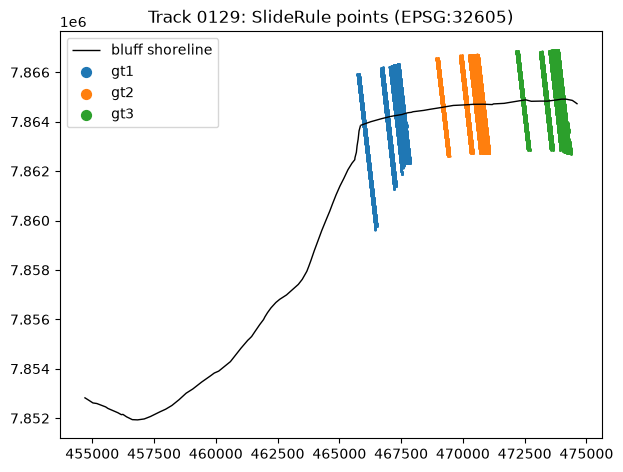

In [6]:
shoreline = load_bluff_shoreline(paths.shoreline_path).to_crs(utm_epsg)
minx, miny, maxx, maxy = beams.total_bounds

fig, ax = plt.subplots(figsize=(7, 7))
shoreline.cx[minx - 2000:maxx + 2000, miny - 2000:maxy + 2000].plot(ax=ax, color="k", linewidth=1, label="bluff shoreline")
for fam, g in beams.groupby("gt_family"):
    g.plot(ax=ax, markersize=0.5, label=fam)
ax.set_title(f"Track {TRACK_ID}: SlideRule points (EPSG:{utm_epsg})")
ax.legend(markerscale=10)
ax.set_aspect("equal")
plt.show()